In [1]:
import pandas as pd
import numpy as np
import re
try:
    from google.colab import files
    uploaded = files.upload()
    FILE = next(iter(uploaded))
except ImportError:
    FILE = "meridian_daily_sales_raw - meridian_daily_sales_raw.csv.csv"
print("Using:", FILE)

Saving meridian_daily_sales_raw - meridian_daily_sales_raw.csv.csv to meridian_daily_sales_raw - meridian_daily_sales_raw.csv.csv
Using: meridian_daily_sales_raw - meridian_daily_sales_raw.csv.csv


In [2]:
df = pd.read_csv(FILE, dtype=str, keep_default_na=False, na_values=[""])
df.columns = df.columns.str.strip().str.lower()
print("Shape:", df.shape)
print(df.dtypes)
df.head()

Shape: (1627, 10)
store_id            object
store_name          object
region              object
date                object
transactions        object
revenue             object
avg_basket_value    object
discount_pct        object
footfall            object
stockout_flag       object
dtype: object


,store_id,store_name,region,date,transactions,revenue,avg_basket_value,discount_pct,footfall,stockout_flag
0,ST-10,MAGNOLIA SQUARE,South,07/03/2026,75,NaN,47.71,38.71096522,374,no
1,ST-13,Highland Court,WEST,27/05/2026,60,4040.14,67.12,15.55684393,528,no
2,ST-16,Redwood Station,West,2026-05-24,74,"$7,132.47",105.29,5.214770493,576,Y
3,ST-14,Golden Valley,West,2026-04-20,49,"$9,117.12",167.74,4.864324242,725,yes
4,ST-04,Silverline Mall,North,04/03/2026,-52,"$2,733.73",2796.6,7.926849185,642,N


In [3]:
def clean_text(s):
    # strip ends and collapse internal runs of whitespace ("Harbor  View" -> "Harbor View")
    return s.str.strip().str.replace(r"\s+", " ", regex=True)

df["store_id"]   = clean_text(df["store_id"]).str.upper()    # IDs: upper case (ST-11)
df["store_name"] = clean_text(df["store_name"]).str.title()  # names: Title Case
df["region"]     = clean_text(df["region"]).str.title()

print(df[["store_id", "store_name", "region"]].drop_duplicates().sort_values("store_id").to_string(index=False))
# Sanity check: each store_id should now map to exactly one name and one region
print("\nstore_ids with >1 name/region:")
print(df.groupby("store_id")[["store_name", "region"]].nunique().query("store_name > 1 or region > 1"))

store_id       store_name region
   ST-01  Riverside Plaza  North
   ST-02     Harbor Point  North
   ST-03   Maple Junction  North
   ST-04  Silverline Mall  North
   ST-05  Eastgate Center  North
   ST-06   Cedar Crossing  North
   ST-07 Sunset Boulevard  South
   ST-08     Palm Terrace  South
   ST-09 Coral Bay Outlet  South
   ST-10  Magnolia Square  South
   ST-11     Willow Creek  South
   ST-12 Bayfront Commons  South
   ST-13   Highland Court   West
   ST-14    Golden Valley   West
   ST-15   Pinecrest Mall   West
   ST-16  Redwood Station   West
   ST-17    Summit Corner   West
   ST-18   Ashbrook Plaza   West

store_ids with >1 name/region:
Empty DataFrame
Columns: [store_name, region]
Index: []


In [4]:
raw_date = clean_text(df["date"])
parsed = pd.Series(pd.NaT, index=df.index, dtype="datetime64[ns]")

for fmt in ["%Y-%m-%d", "%Y/%m/%d", "%d-%b-%Y", "%d %b %Y", "%b %d %Y", "%b %d, %Y", "%d-%B-%Y", "%B %d, %Y"]:
    todo = parsed.isna()
    parsed[todo] = pd.to_datetime(raw_date[todo], format=fmt, errors="coerce")

# Numeric day/month formats
slash = parsed.isna() & raw_date.str.match(r"^\d{1,2}[/-]\d{1,2}[/-]\d{4}$", na=False)
parts = raw_date[slash].str.split(r"[/-]", expand=True).astype(int) if slash.any() else pd.DataFrame(columns=[0, 1, 2])
must_be_dmy = parts[0] > 12
must_be_mdy = parts[1] > 12
ambiguous   = ~must_be_dmy & ~must_be_mdy
print(f"Numeric-slash dates: {slash.sum()} | clearly D/M/Y: {must_be_dmy.sum()} | "
      f"clearly M/D/Y: {must_be_mdy.sum()} | ambiguous: {ambiguous.sum()}")

Numeric-slash dates: 540 | clearly D/M/Y: 168 | clearly M/D/Y: 142 | ambiguous: 230


In [5]:
missing = pd.DataFrame({"n_missing": df.isna().sum(), "pct": (df.isna().mean() * 100).round(1)})
print(missing)

                  n_missing  pct
store_id                  0  0.0
store_name                0  0.0
region                    0  0.0
date                      0  0.0
transactions              0  0.0
revenue                  53  3.3
avg_basket_value          0  0.0
discount_pct              0  0.0
footfall                  0  0.0
stockout_flag             0  0.0


In [6]:
#make revenue numeric USD
def parse_usd(x):
    """'$1,234.50', '1234.5 USD', 'USD 1,234', '1.2k', '(120.00)' -> float. Returns NaN if unparseable."""
    if pd.isna(x):
        return np.nan
    s = str(x).strip().upper()
    if s in {"", "NA", "N/A", "NULL", "NONE", "-", "NAN"}:
        return np.nan
    neg = s.startswith("(") and s.endswith(")")
    s = re.sub(r"USD|US\$|\$|,|\(|\)|\s", "", s)
    mult = 1
    if s.endswith("K"):
        mult, s = 1_000, s[:-1]
    elif s.endswith("M"):
        mult, s = 1_000_000, s[:-1]
    try:
        v = float(s) * mult
    except ValueError:
        return np.nan
    return -v if neg else v

df["revenue_raw"] = df["revenue"]
df["revenue"] = df["revenue_raw"].apply(parse_usd)

was_text = df["revenue_raw"].notna() & ~df["revenue_raw"].str.strip().str.fullmatch(r"-?\d+(\.\d+)?", na=False)
print(f"Text-currency entries converted: {(was_text & df['revenue'].notna()).sum()}")
failed = df["revenue_raw"].notna() & df["revenue"].isna()
print(f"Non-blank entries that could NOT be parsed: {failed.sum()}")
if failed.any():
    print(df.loc[failed, "revenue_raw"].unique())

Text-currency entries converted: 312
Non-blank entries that could NOT be parsed: 173
['INR 2,213' 'INR 3,341' 'INR 5,400' 'INR 2,200' 'INR 5,365' 'INR 3,074'
 'INR 2,619' 'INR 8,140' 'INR 4,601' 'INR 6,025' 'INR 9,570' 'INR 6,184'
 'INR 5,580' 'INR 3,109' 'INR 6,002' 'INR 3,935' 'INR 3,472' 'INR 4,143'
 'INR 3,807' 'INR 3,610' 'INR 3,646' 'INR 5,638' 'INR 5,309' 'INR 3,974'
 'INR 6,607' 'INR 3,829' 'INR 3,215' 'INR 11,211' 'INR 16,395' 'INR 2,492'
 'INR 4,238' 'INR 1,704' 'INR 5,111' 'INR 3,662' 'INR 5,997' 'INR 4,259'
 'INR 2,773' 'INR 5,320' 'INR 3,851' 'INR 5,475' 'INR 7,165' 'INR 4,287'
 'INR 2,726' 'INR 12,900' 'INR 3,886' 'INR 5,981' 'INR 5,529' 'INR 9,428'
 'INR 3,363' 'INR 3,606' 'INR 11,332' 'INR 6,951' 'INR 4,873' 'INR 7,227'
 'INR 4,443' 'INR 2,098' 'INR 4,495' 'INR 4,945' 'INR 5,072' 'INR 4,501'
 'INR 4,077' 'INR 6,570' 'INR 8,601' 'INR 4,183' 'INR 7,774' 'INR 4,715'
 'INR 1,801' 'INR 3,710' 'INR 3,963' 'INR 4,792' 'INR 8,760' 'INR 4,241'
 'INR 13,156' 'INR 3,260' 'INR 4,42

In [7]:
print("Raw values:", df["stockout_flag"].value_counts(dropna=False).to_dict())
truthy = {"y", "yes", "true", "t", "1", "1.0"}
falsy  = {"n", "no", "false", "f", "0", "0.0"}
s = df["stockout_flag"].astype(str).str.strip().str.lower()
df["stockout_flag"] = pd.Series(pd.NA, index=df.index, dtype="boolean")   # nullable boolean
df.loc[s.isin(truthy), "stockout_flag"] = True
df.loc[s.isin(falsy),  "stockout_flag"] = False
print("Cleaned:", df["stockout_flag"].value_counts(dropna=False).to_dict())

Raw values: {'N': 636, '0': 249, 'no': 176, 'Y': 167, 'yes': 163, 'TRUE': 87, '1': 78, 'FALSE': 71}
Cleaned: {np.False_: 1132, np.True_: 495}


In [9]:
#find and remove the duplicate ST-11 week

raw_again = pd.read_csv(FILE, dtype=str)
raw_again.columns = raw_again.columns.str.strip().str.lower()
print("Exact duplicates in RAW file (casing differs):", raw_again.duplicated().sum())
print("Duplicates on (store_id, date) AFTER standardizing:", df.duplicated(["store_id", "date"]).sum())

key_dups = df[df.duplicated(["store_id", "date"], keep=False)].sort_values(["store_id", "date"])
print("\nStores/dates involved:")
print(key_dups.groupby("store_id")["date"].agg(["min", "max", "count"]))


Exact duplicates in RAW file (casing differs): 0
Duplicates on (store_id, date) AFTER standardizing: 9

Stores/dates involved:
                 min         max  count
store_id                               
ST-06     05/03/2026  05/03/2026      2
ST-09     05/03/2026  05/03/2026      2
ST-11     10/03/2026    9-Mar-26     14


In [10]:
# Do the duplicate pairs carry the same numbers? If yes, it's a pure re-entry and safe to drop.
value_cols = ["store_name", "region", "revenue", "transactions", "discount_pct", "stockout_flag"]
conflicts = key_dups.groupby(["store_id", "date"])[value_cols].nunique(dropna=False).gt(1).any(axis=1)
print(f"Duplicate (store, date) groups with conflicting values: {conflicts.sum()} of {len(conflicts)}")
before = len(df)
df = df.drop_duplicates(subset=["store_id", "date"], keep="first").reset_index(drop=True)
after = len(df)
print(f"Rows before: {before} | after: {after} | removed: {before - after}")

Duplicate (store, date) groups with conflicting values: 2 of 9
Rows before: 1627 | after: 1618 | removed: 9


In [11]:
# data-entry errors in transactions and discount_pct
df["transactions"] = pd.to_numeric(df["transactions"], errors="coerce")
df["discount_pct"] = pd.to_numeric(df["discount_pct"].astype(str).str.replace("%", "").str.strip(), errors="coerce")

df["err_transactions_negative"] = df["transactions"] < 0
df["err_discount_out_of_range"] = ~df["discount_pct"].between(0, 100) & df["discount_pct"].notna()
print("Negative transactions:", df["err_transactions_negative"].sum())
print("discount_pct outside [0,100]:", df["err_discount_out_of_range"].sum())
df.loc[df.err_transactions_negative | df.err_discount_out_of_range,
       ["store_id", "date", "revenue", "transactions", "discount_pct"]]

Negative transactions: 14
discount_pct outside [0,100]: 39


,store_id,date,revenue,transactions,discount_pct
4,ST-04,04/03/2026,2733.73,-52,7.926849
90,ST-14,03/04/2026,5952.86,-53,36.211743
121,ST-06,04/06/2026,6308.85,70,250.000000
140,ST-08,20260503,2774.78,54,-15.000000
155,ST-11,07/04/2026,10294.17,26,250.000000
170,ST-13,20260326,NaN,66,250.000000
194,ST-07,11-May-26,6613.42,58,-15.000000
210,ST-11,05/16/2026,NaN,66,250.000000
258,ST-05,20260312,3279.98,44,250.000000
276,ST-07,14-May-26,3362.98,71,-15.000000


In [12]:
#Step 8: save and report

df = df.sort_values(["store_id", "date"]).reset_index(drop=True)
front = ["store_id", "store_name", "region", "date", "revenue", "transactions", "discount_pct", "stockout_flag"]
audit = [c for c in df.columns if c not in front]
df = df[front + audit]

OUT = "meridian_daily_sales_clean.csv"
df.to_csv(OUT, index=False, date_format="%Y-%m-%d")
print("Final row count:", len(df))
print("Final shape:", df.shape)
print(df.dtypes)
try:
    files.download(OUT)
except NameError:
    pass

Final row count: 1618
Final shape: (1618, 13)
store_id                      object
store_name                    object
region                        object
date                          object
revenue                      float64
transactions                   int64
discount_pct                 float64
stockout_flag                boolean
avg_basket_value              object
footfall                      object
revenue_raw                   object
err_transactions_negative       bool
err_discount_out_of_range       bool
dtype: object


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
# ---- Setup ----
import pandas as pd, numpy as np,datetime as dt, matplotlib.pyplot as plt
if "df" not in globals():
    from google.colab import files
    up = files.upload()                      # choose meridian_daily_sales_clean.csv
    df = pd.read_csv(next(iter(up)))
d = df.copy()
d["date"] = pd.to_datetime(d["date"], format="mixed", errors="coerce")
d["revenue"] = pd.to_numeric(d["revenue"], errors="coerce")
# footfall wasn't touched in Part 1, so clean it here the same way (strip commas/spaces)
d["footfall"] = pd.to_numeric(d["footfall"].astype(str).str.replace(r"[,\s]", "", regex=True), errors="coerce")
print(d.shape, "| revenue NaN:", d["revenue"].isna().sum(), "| footfall NaN:", d["footfall"].isna().sum())

def quartiles(s):
    s = s.dropna()
    q1, q2, q3 = s.quantile([0.25, 0.50, 0.75])   # pandas default = linear interpolation
    return q1, q2, q3, q3 - q1

def fences(s, k=1.5):
    q1, q2, q3, iqr = quartiles(s)
    return q1 - k * iqr, q3 + k * iqr

(1618, 13) | revenue NaN: 226 | footfall NaN: 0


In [16]:
# ---- Q9: Q1, Q2, Q3, IQR for revenue + hand check on one store ----
q1, q2, q3, iqr = quartiles(d["revenue"])
print(f"ALL STORES  n={d['revenue'].notna().sum()}  Q1={q1:,.2f}  Q2={q2:,.2f}  Q3={q3:,.2f}  IQR={iqr:,.2f}")

# Hand check: redo the calculation step by step for one store, then compare with pandas.
CHECK_STORE = "ST-11"
v = np.sort(d.loc[d.store_id == CHECK_STORE, "revenue"].dropna().to_numpy())
n = len(v)
print(f"\n{CHECK_STORE}: n={n}, sorted values:\n{np.round(v, 2)}")

def hand_quantile(v, p):
    # Linear method: position h = (n-1)*p on the 0-indexed sorted list,
    # answer = v[floor(h)] + (h - floor(h)) * (v[floor(h)+1] - v[floor(h)])
    h = (len(v) - 1) * p
    lo = int(np.floor(h)); frac = h - lo
    hi = min(lo + 1, len(v) - 1)
    val = v[lo] + frac * (v[hi] - v[lo])
    print(f"  p={p:.2f}: h=({len(v)}-1)*{p}={h:.2f} -> v[{lo}]={v[lo]:.2f} + {frac:.2f}*({v[hi]:.2f}-{v[lo]:.2f}) = {val:.2f}")
    return val

hq1, hq2, hq3 = (hand_quantile(v, p) for p in (0.25, 0.5, 0.75))
cq1, cq2, cq3, ciqr = quartiles(pd.Series(v))
print(f"\n{'':6}{'by hand':>12}{'pandas':>12}{'match':>7}")
for name, a, b in [("Q1", hq1, cq1), ("Q2", hq2, cq2), ("Q3", hq3, cq3), ("IQR", hq3 - hq1, ciqr)]:
    print(f"{name:6}{a:12,.2f}{b:12,.2f}{str(np.isclose(a, b)):>7}")
print(f"\nInterpretation: the middle 50% of all store-days earned between ${q1:,.0f} and ${q3:,.0f} "
      f"(a ${iqr:,.0f} spread around a typical day of ${q2:,.0f}); the hand calculation matches pandas exactly.")

ALL STORES  n=1392  Q1=3,583.11  Q2=4,938.47  Q3=6,925.41  IQR=3,342.30

ST-11: n=74, sorted values:
[ 2836.43  3126.29  3466.81  3522.29  3544.89  3545.98  3779.56  3787.9
  3853.48  3863.54  3899.69  4041.88  4178.26  4223.97  4330.22  4353.11
  4396.7   4399.62  4436.22  4481.55  4502.07  4515.15  4536.3   4594.66
  4665.13  4694.19  4711.58  4881.27  4976.23  5153.49  5189.33  5206.59
  5416.18  5423.32  5436.78  5820.11  5945.06  6036.47  6071.05  6159.44
  6291.91  6459.09  6662.31  6670.09  6701.61  6786.01  6830.02  6905.48
  6997.08  7242.82  7340.68  7526.22  7725.34  7802.41  8036.    8321.59
  8701.5   8752.46  8959.7   9503.12  9535.19  9608.74  9778.61 10294.17
 10442.1  10541.49 11006.32 11092.03 11837.54 12054.82 12651.57 13174.94
 13452.67 14158.45]
  p=0.25: h=(74-1)*0.25=18.25 -> v[18]=4436.22 + 0.25*(4481.55-4436.22) = 4447.55
  p=0.50: h=(74-1)*0.5=36.50 -> v[36]=5945.06 + 0.50*(6036.47-5945.06) = 5990.77
  p=0.75: h=(74-1)*0.75=54.75 -> v[54]=8036.00 + 0.75*(8321.

In [17]:
# ---- Q10: 1.5 x IQR fences for revenue ----
rev_lo, rev_hi = fences(d["revenue"])
print(f"Lower fence = Q1 - 1.5*IQR = {q1:,.2f} - 1.5*{iqr:,.2f} = {rev_lo:,.2f}")
print(f"Upper fence = Q3 + 1.5*IQR = {q3:,.2f} + 1.5*{iqr:,.2f} = {rev_hi:,.2f}")
print(f"\nInterpretation: any store-day with revenue below ${rev_lo:,.0f} or above ${rev_hi:,.0f} "
      f"is unusual relative to the rest of the chain." +
      (" The lower fence is negative, so only high days can be flagged on the low side." if rev_lo < 0 else ""))

Lower fence = Q1 - 1.5*IQR = 3,583.11 - 1.5*3,342.30 = -1,430.34
Upper fence = Q3 + 1.5*IQR = 6,925.41 + 1.5*3,342.30 = 11,938.86

Interpretation: any store-day with revenue below $-1,430 or above $11,939 is unusual relative to the rest of the chain. The lower fence is negative, so only high days can be flagged on the low side.


In [20]:
# Q11: every revenue outlier
d["rev_outlier"] = (d["revenue"] < rev_lo) | (d["revenue"] > rev_hi)
d["rev_outlier_side"] = np.where(d["revenue"] > rev_hi, "high", np.where(d["revenue"] < rev_lo, "low", ""))
out = d.loc[d.rev_outlier, ["store_id", "store_name", "region", "date", "revenue", "rev_outlier_side", "revenue"]]
print(f"Revenue outliers: {len(out)} of {len(d)} rows ({len(out)/len(d):.1%})\n")
print(out.sort_values(["store_id", "date"]).to_string(index=False))
print("\nBy store:"); print(out.groupby(["store_id", "rev_outlier_side"]).size().unstack(fill_value=0))
by_store = out.groupby("store_id").size()
top_share = by_store.max() / max(len(out), 1)
if top_share > 0.5:
    print(f"\nInterpretation: {len(out)} store-days are flagged, but {by_store.idxmax()} alone accounts for {top_share:.0%} of them — "
          f"that points to a store whose normal level differs from the chain, not to isolated unusual days.")
else:
    print(f"\nInterpretation: {len(out)} store-days ({len(out)/len(d):.1%}) fall outside the fences, spread across {by_store.size} store(s) "
          f"({', '.join(by_store.index)}) — isolated unusual days rather than one abnormal store.")

Revenue outliers: 60 of 1618 rows (3.7%)

store_id       store_name region       date  revenue rev_outlier_side  revenue
   ST-01  Riverside Plaza  North 2026-04-07 12183.51             high 12183.51
   ST-02     Harbor Point  North 2026-03-31 12052.49             high 12052.49
   ST-02     Harbor Point  North 2026-04-03 12008.83             high 12008.83
   ST-02     Harbor Point  North 2026-04-03 13008.95             high 13008.95
   ST-02     Harbor Point  North 2026-04-17 13032.04             high 13032.04
   ST-02     Harbor Point  North 2026-05-13 13800.45             high 13800.45
   ST-02     Harbor Point  North 2026-05-24 12016.48             high 12016.48
   ST-03   Maple Junction  North 2026-04-02 13195.16             high 13195.16
   ST-03   Maple Junction  North 2026-04-11 13815.29             high 13815.29
   ST-03   Maple Junction  North 2026-05-19 14250.38             high 14250.38
   ST-03   Maple Junction  North 2026-05-20 12347.36             high 12347.36
   ST-06  

In [21]:
# Q12: same fences for footfall — does it catch the ~40,000 sensor faults? ----
print("Largest footfall values (to see the sensor-fault cluster):")
print(d["footfall"].nlargest(12).to_string())

# Definition of a sensor fault (check it against the list above and adjust if needed):
# a reading at/above 30,000, i.e. an order of magnitude above normal traffic, near the known ~40,000 fault value.
SENSOR_FAULT_MIN = 30_000
d["sensor_fault"] = d["footfall"] >= SENSOR_FAULT_MIN

fq1, fq2, fq3, fiqr = quartiles(d["footfall"])
ff_lo, ff_hi = fences(d["footfall"])
d["ff_outlier"] = (d["footfall"] < ff_lo) | (d["footfall"] > ff_hi)
print(f"\nFootfall  Q1={fq1:,.1f}  Q2={fq2:,.1f}  Q3={fq3:,.1f}  IQR={fiqr:,.1f}")
print(f"Fences: [{ff_lo:,.1f}, {ff_hi:,.1f}]")
caught = (d.sensor_fault & d.ff_outlier).sum(); total_f = d.sensor_fault.sum()
print(f"Sensor-fault days: {total_f} | caught by fence: {caught} | missed: {total_f - caught}")
print(f"Other (non-fault) footfall outliers: {(d.ff_outlier & ~d.sensor_fault).sum()}")
print(d.loc[d.sensor_fault, ["store_id", "date", "footfall", "revenue"]].to_string(index=False))
print(f"\nInterpretation: {'yes — all' if caught == total_f else f'only {caught} of'} {total_f} sensor-fault days "
      f"exceed the upper fence of {ff_hi:,.0f}; a 40,000 reading is about {40000/fq2:.0f}x a typical day, so it is impossible to miss.")

Largest footfall values (to see the sensor-fault cluster):
727     41631
804     41562
745     39530
495      1083
1191     1045
1226     1033
1576      991
103       990
383       989
857       988
53        982
737       982

Footfall  Q1=496.0  Q2=603.0  Q3=700.0  IQR=204.0
Fences: [190.0, 1,006.0]
Sensor-fault days: 3 | caught by fence: 3 | missed: 0
Other (non-fault) footfall outliers: 7
store_id       date  footfall  revenue
   ST-09 2026-04-03     41631 15033.05
   ST-09 2026-03-15     39530      NaN
   ST-09 2026-05-21     41562  5910.82

Interpretation: yes — all 3 sensor-fault days exceed the upper fence of 1,006; a 40,000 reading is about 66x a typical day, so it is impossible to miss.


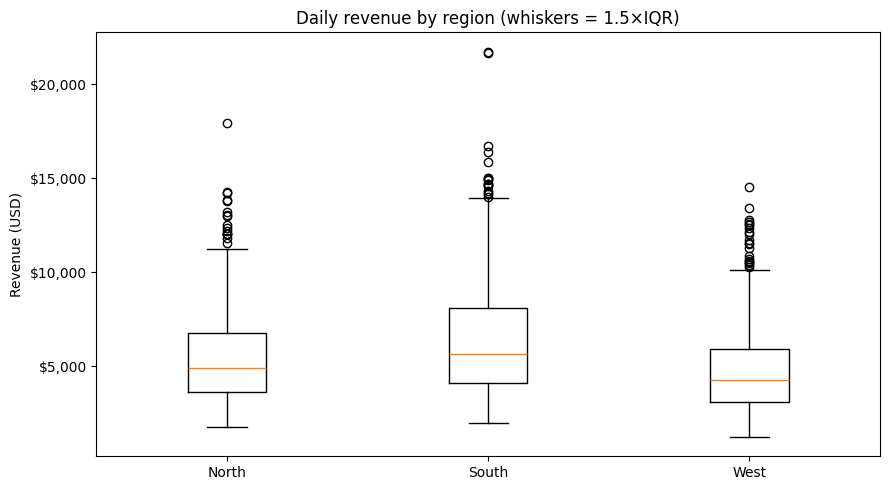

          n      Q1  median      Q3     IQR  stores
region                                             
South   466  4143.0  5664.0  8079.0  3937.0       6
North   472  3632.0  4894.0  6753.0  3122.0       6
West    454  3124.0  4275.0  5939.0  2815.0       6

Interpretation: South has the widest IQR ($3,937 vs West's $2,815): a normal day's revenue there is the least predictable, mostly because its stores run at different levels (medians $4,623 apart vs $3,490 average IQR within each store).


In [22]:
# Q13: box plot of revenue by region ----
regions = sorted(d["region"].dropna().unique())
fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot([d.loc[d.region == r, "revenue"].dropna() for r in regions], whis=1.5)
ax.set_xticks(range(1, len(regions) + 1), regions)
ax.set_title("Daily revenue by region (whiskers = 1.5×IQR)"); ax.set_ylabel("Revenue (USD)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout(); plt.show()

reg = d.groupby("region")["revenue"].agg(n="count",
        Q1=lambda s: s.quantile(.25), median="median", Q3=lambda s: s.quantile(.75))
reg["IQR"] = reg.Q3 - reg.Q1
reg["stores"] = d.groupby("region")["store_id"].nunique()
reg = reg.sort_values("IQR", ascending=False)
print(reg.round(0).to_string())
w = reg.index[0]
ws = d[d.region == w].groupby("store_id")["revenue"]
gap = ws.median().max() - ws.median().min()
within = (ws.quantile(.75) - ws.quantile(.25)).mean()
why = (f"mostly because its stores run at different levels (medians ${gap:,.0f} apart vs ${within:,.0f} average IQR within each store)"
       if gap > within else f"because its stores are individually volatile (average within-store IQR ${within:,.0f})")
print(f"\nInterpretation: {w} has the widest IQR (${reg.IQR.iloc[0]:,.0f} vs {reg.index[-1]}'s ${reg.IQR.iloc[-1]:,.0f}): a normal day's revenue "
      f"there is the least predictable, {why}.")

In [23]:
# Why is that region wide? Compare its stores' medians (mixing a big and a small store widens the IQR).
print(d[d.region == w].groupby("store_id")["revenue"].describe()[["count", "25%", "50%", "75%"]].round(0))

          count     25%     50%      75%
store_id                                
ST-07      76.0  5375.0  7070.0   9800.0
ST-08      80.0  2812.0  3578.0   4906.0
ST-09      75.0  5085.0  6343.0   8211.0
ST-10      84.0  3240.0  4528.0   5559.0
ST-11      74.0  4448.0  5991.0   8250.0
ST-12      77.0  5808.0  8201.0  10980.0


In [24]:
# Q14: the consistently high store that is never flagged ----
st = d.groupby("store_id").agg(median_rev=("revenue", "median"), min_rev=("revenue", "min"),
                               max_rev=("revenue", "max"), outliers=("rev_outlier", "sum"))
st = st.sort_values("median_rev", ascending=False)
print(st.round(0).to_string())
unflagged = st[st.outliers == 0]
top = unflagged.index[0] if len(unflagged) else st.index[0]   # highest-median store with no flags
t = st.loc[top]
print(f"\nStore examined: {top} (rank {list(st.index).index(top)+1} of {len(st)} by median revenue, {int(t.outliers)} flagged days)")
share_above_q3 = (d.loc[d.revenue > q3, "store_id"] == top).mean()
print(f"\n{top}: median ${t.median_rev:,.0f} vs chain median ${q2:,.0f} | its max ${t.max_rev:,.0f} vs upper fence ${rev_hi:,.0f}")
print(f"{top} supplies {share_above_q3:.0%} of all store-days above the chain Q3 — its high days are part of what defines the upper quartile.")

# The same store judged against its OWN distribution:
s_lo, s_hi = fences(d.loc[d.store_id == top, "revenue"])
print(f"{top} own fences: [{s_lo:,.0f}, {s_hi:,.0f}]; days outside them: "
      f"{((d.store_id == top) & ~d.revenue.between(s_lo, s_hi)).sum()}")
print(f"\nInterpretation: {top}'s best day (${t.max_rev:,.0f}) is still under the chain fence (${rev_hi:,.0f}) because its steady high days "
      f"make up the chain's upper quartile rather than sticking out beyond it; the IQR rule asks 'is this DAY unusual?', not 'is this STORE "
      f"different?', so not flagging it is correct behaviour, not a false negative.")

          median_rev  min_rev  max_rev  outliers
store_id                                        
ST-12         8201.0   4083.0  15876.0        15
ST-07         7070.0   3363.0  21722.0         9
ST-09         6343.0   3331.0  15033.0         8
ST-03         6263.0   3028.0  14250.0         4
ST-11         5991.0   2836.0  14158.0         5
ST-02         5950.0   2368.0  13800.0         6
ST-14         5410.0   2784.0  12576.0         1
ST-16         5386.0   2786.0  14538.0         5
ST-01         5283.0   2965.0  12184.0         1
ST-17         5183.0   2658.0  13413.0         3
ST-06         4970.0   2211.0  17918.0         3
ST-13         4927.0   2559.0  10540.0         0
ST-10         4528.0   2011.0  11228.0         0
ST-05         4343.0   1859.0   9365.0         0
ST-08         3578.0   2009.0   9965.0         0
ST-15         3361.0   1712.0   7683.0         0
ST-04         3269.0   1765.0  10746.0         0
ST-18         2782.0   1249.0   7407.0         0

Store examined: ST-

In [25]:
# ---- Q15: recompute fences without the sensor-fault days ----
clean = d.loc[~d.sensor_fault]
rows = []
for col in ["footfall", "revenue"]:
    for label, data in [("with faults", d), ("faults removed", clean)]:
        a, b, c, i = quartiles(data[col]); lo, hi = fences(data[col])
        rows.append(dict(column=col, data=label, n=data[col].notna().sum(), Q1=a, Q3=c, IQR=i,
                         lower=lo, upper=hi, mean=data[col].mean(), sd=data[col].std()))
cmp = pd.DataFrame(rows).set_index(["column", "data"])
print(cmp.round(1).to_string())

f_with, f_clean = cmp.loc[("footfall", "with faults")], cmp.loc[("footfall", "faults removed")]
print(f"\nFootfall upper fence moved {f_with.upper - f_clean.upper:,.1f} "
      f"({(f_with.upper - f_clean.upper)/f_clean.upper:.1%}); lower fence moved {f_with.lower - f_clean.lower:,.1f}.")
print(f"By contrast the footfall MEAN moved {f_with['mean'] - f_clean['mean']:,.1f} "
      f"({(f_with['mean'] - f_clean['mean'])/f_clean['mean']:.1%}) and the SD moved "
      f"{f_with.sd - f_clean.sd:,.1f} ({(f_with.sd - f_clean.sd)/f_clean.sd:.0%}).")
print(f"\nInterpretation: removing {d.sensor_fault.sum()} extreme days barely moves the IQR fences, because quartiles depend on "
      f"rank, not size — a 40,000 reading counts the same as any other high value; mean/SD-based cut-offs are the ones a handful of extremes distorts.")

                            n      Q1      Q3     IQR   lower    upper    mean      sd
column   data                                                                         
footfall with faults     1618   496.0   700.0   204.0   190.0   1006.0   675.2  1741.5
         faults removed  1615   495.5   700.0   204.5   188.8   1006.8   600.4   149.8
revenue  with faults     1392  3583.1  6925.4  3342.3 -1430.3  11938.9  5639.5  2848.5
         faults removed  1390  3581.8  6921.7  3339.9 -1428.0  11931.5  5632.6  2839.4

Footfall upper fence moved -0.8 (-0.1%); lower fence moved 1.2.
By contrast the footfall MEAN moved 74.7 (12.4%) and the SD moved 1,591.7 (1063%).

Interpretation: removing 3 extreme days barely moves the IQR fences, because quartiles depend on rank, not size — a 40,000 reading counts the same as any other high value; mean/SD-based cut-offs are the ones a handful of extremes distorts.


In [27]:
# ---- Q16: numbers behind the board-report recommendation ----
tot = d["revenue"].sum()
hi_rows, lo_rows = d[d.rev_outlier_side == "high"], d[d.rev_outlier_side == "low"]
print(f"Total revenue:                     ${tot:,.0f}")
print(f"Revenue from {len(hi_rows)} high-outlier days:   ${hi_rows.revenue.sum():,.0f} ({hi_rows.revenue.sum()/tot:.2%} of total)")
print(f"Revenue from {len(lo_rows)} low-outlier days:    ${lo_rows.revenue.sum():,.0f} ({lo_rows.revenue.sum()/tot:.2%} of total)")
print(f"Total if outliers were dropped:    ${d.loc[~d.rev_outlier, 'revenue'].sum():,.0f}  "
      f"(understates actual by {d.loc[d.rev_outlier,'revenue'].sum()/tot:.2%})")
print(f"Mean daily revenue with / without: ${d.revenue.mean():,.0f} / ${d.loc[~d.rev_outlier,'revenue'].mean():,.0f}")
print(f"Median daily revenue with / without: ${d.revenue.median():,.0f} / ${d.loc[~d.rev_outlier,'revenue'].median():,.0f}")
print(f"Outliers that were imputed values: {d.loc[d.rev_outlier, 'revenue'].sum()}")

print(f"\nInterpretation: dropping the {int(d.rev_outlier.sum())} flagged days would understate revenue by "
      f"{d.loc[d.rev_outlier,'revenue'].sum()/tot:.1%} while the median barely moves (${d.revenue.median():,.0f} -> "
      f"${d.loc[~d.rev_outlier,'revenue'].median():,.0f}), so they should stay in totals and be explained, not deleted.")

Total revenue:                     $7,850,234
Revenue from 60 high-outlier days:   $827,564 (10.54% of total)
Revenue from 0 low-outlier days:    $0 (0.00% of total)
Total if outliers were dropped:    $7,022,670  (understates actual by 10.54%)
Mean daily revenue with / without: $5,640 / $5,272
Median daily revenue with / without: $4,938 / $4,800
Outliers that were imputed values: 827563.99

Interpretation: dropping the 60 flagged days would understate revenue by 10.5% while the median barely moves ($4,938 -> $4,800), so they should stay in totals and be explained, not deleted.


In [37]:
# Q17 - Mean, Median and Mode of Revenue

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load CSV
from google.colab import files

uploaded = files.upload()

file_name = next(iter(uploaded))
df = pd.read_csv(file_name)

# Make a copy
d = df.copy()

# Clean revenue
d["revenue"] = pd.to_numeric(
    d["revenue"],
    errors="coerce"
)

# Remove missing revenue values
revenue = d["revenue"].dropna()

# Calculate statistics
mean_revenue = revenue.mean()
median_revenue = revenue.median()

mode_values = revenue.mode()

print("Q17 - Revenue Summary")
print("-" * 40)

print(f"Mean   : {mean_revenue:.2f}")
print(f"Median : {median_revenue:.2f}")
print(f"Mode   : {mode_values.tolist()}")

# Determine highest and lowest
stats = {
    "Mean": mean_revenue,
    "Median": median_revenue,
    "Mode": mode_values.iloc[0] if len(mode_values) > 0 else np.nan
}

print("\nOrdering:")
for name, value in sorted(stats.items(), key=lambda x: x[1], reverse=True):
    print(f"{name}: {value:.2f}")

highest = max(stats, key=stats.get)
lowest = min(stats, key=stats.get)

print(f"\nHighest : {highest}")
print(f"Lowest  : {lowest}")


# Interpretation: If the ordering is Mean > Median > Mode, it indicates a right-skewed (positively skewed) revenue distribution because
# unusually high revenue days pull the mean upward.

Saving meridian_daily_sales_raw - meridian_daily_sales_raw.csv.csv to meridian_daily_sales_raw - meridian_daily_sales_raw.csv (2).csv
Q17 - Revenue Summary
----------------------------------------
Mean   : 5690.56
Median : 4970.34
Mode   : [2836.43, 3853.48, 4175.45, 4353.11, 4665.13, 5416.18, 6159.44]

Ordering:
Mean: 5690.56
Median: 4970.34
Mode: 2836.43

Highest : Mean
Lowest  : Mode


In [29]:
# Q18 - Revenue skewness

revenue_skewness = revenue.skew()

print("Q18 - Revenue Skewness")
print("-" * 40)

print(f"Skewness coefficient: {revenue_skewness:.4f}")

# Interpret skewness
if revenue_skewness > 1:
    strength = "strong"
    direction = "right-skewed"
elif revenue_skewness > 0.5:
    strength = "moderate"
    direction = "right-skewed"
elif revenue_skewness > 0:
    strength = "mild"
    direction = "right-skewed"
elif revenue_skewness < -1:
    strength = "strong"
    direction = "left-skewed"
elif revenue_skewness < -0.5:
    strength = "moderate"
    direction = "left-skewed"
elif revenue_skewness < 0:
    strength = "mild"
    direction = "left-skewed"
else:
    strength = "approximately none"
    direction = "approximately symmetric"

print(f"Direction: {direction}")
print(f"Strength : {strength}")


# Interpretation: A positive skewness coefficient means revenue has a longer tail toward unusually high revenue values, while a negative coefficient means the
#  tail extends toward unusually low values.


Q18 - Revenue Skewness
----------------------------------------
Skewness coefficient: 1.3647
Direction: right-skewed
Strength : strong


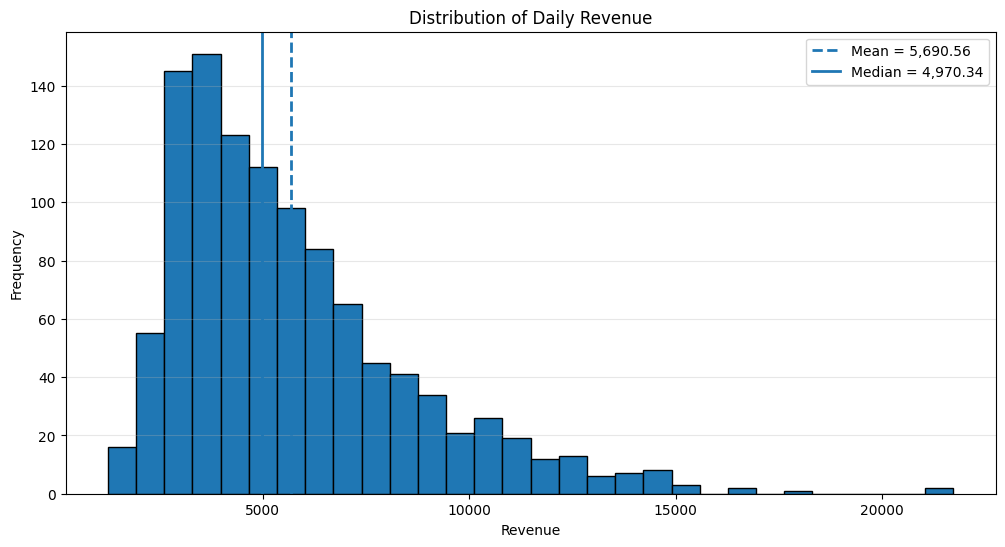

In [30]:
# Q19 - Histogram of Revenue with Mean and Median

plt.figure(figsize=(12, 6))

plt.hist(
    revenue,
    bins=30,
    edgecolor="black"
)

plt.axvline(
    mean_revenue,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_revenue:,.2f}"
)

plt.axvline(
    median_revenue,
    linestyle="-",
    linewidth=2,
    label=f"Median = {median_revenue:,.2f}"
)

plt.title("Distribution of Daily Revenue")
plt.xlabel("Revenue")
plt.ylabel("Frequency")

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

# Interpretation: If the histogram has a long tail toward higher revenue values and the mean lies to the right of the median

In [31]:
# Q20 - Compare mean and median

print("Q20 - Mean vs Median")
print("-" * 40)

print(f"Mean revenue   : {mean_revenue:,.2f}")
print(f"Median revenue : {median_revenue:,.2f}")
print(f"Skewness       : {revenue_skewness:.4f}")

if abs(revenue_skewness) > 0.5:
    recommended_measure = "Median"
else:
    recommended_measure = "Mean"

print(f"\nSuggested single-number measure: {recommended_measure}")


# Interpretation: When daily revenue is substantially skewed, the median is generally a fairer representation of a typical day because
# it is less affected by unusually large or small revenue days.

Q20 - Mean vs Median
----------------------------------------
Mean revenue   : 5,690.56
Median revenue : 4,970.34
Skewness       : 1.3647

Suggested single-number measure: Median


In [34]:
# Clean footfall
d["footfall"] = pd.to_numeric(
    d["footfall"].astype(str).str.replace(r"[,\s]", "", regex=True),
    errors="coerce"
)

# Before removing sensor faults
footfall_before = d["footfall"].dropna()

skew_before = footfall_before.skew()

# Remove sensor-fault days
clean_footfall = d.loc[
    d["stockout_flag"] != True,
    "footfall"
].dropna()

skew_after = clean_footfall.skew()

change = skew_after - skew_before

print("Q21 - Footfall Skewness")
print("-" * 40)

print(f"Skewness before removing sensor-fault days : {skew_before:.4f}")
print(f"Skewness after removing sensor-fault days  : {skew_after:.4f}")
print(f"Change in skewness                        : {change:+.4f}")
print(f"Absolute change                           : {abs(change):.4f}")



# Interpretation: The change in skewness quantifies how much the stockout-flag observations were distorting the shape of the footfall distribution.



Q21 - Footfall Skewness
----------------------------------------
Skewness before removing sensor-fault days : 23.0054
Skewness after removing sensor-fault days  : 23.0054
Change in skewness                        : +0.0000
Absolute change                           : 0.0000


In [35]:
# Q22 - Useful numbers for manager explanation

max_revenue = revenue.max()
min_revenue = revenue.min()

print("Q22 - Revenue distribution")
print("-" * 40)

print(f"Typical daily revenue (median): {median_revenue:,.2f}")
print(f"Average daily revenue (mean)  : {mean_revenue:,.2f}")
print(f"Highest daily revenue         : {max_revenue:,.2f}")
print(f"Lowest daily revenue          : {min_revenue:,.2f}")

Q22 - Revenue distribution
----------------------------------------
Typical daily revenue (median): 4,970.34
Average daily revenue (mean)  : 5,690.56
Highest daily revenue         : 21,721.54
Lowest daily revenue          : 1,248.74


In [36]:
# Q23 - REGION-WISE MEDIAN REVENUE, IQR AND OUTLIER COUNT
d["revenue"] = pd.to_numeric(
    d["revenue"],
    errors="coerce"
)

# Calculate global revenue fences if they don't already exist
if "rev_lo" not in globals() or "rev_hi" not in globals():

    revenue_clean = d["revenue"].dropna()

    q1_global = revenue_clean.quantile(0.25)
    q3_global = revenue_clean.quantile(0.75)

    iqr_global = q3_global - q1_global

    rev_lo = q1_global - 1.5 * iqr_global
    rev_hi = q3_global + 1.5 * iqr_global

    print("Revenue fences calculated:")
    print(f"Lower fence: {rev_lo:,.2f}")
    print(f"Upper fence: {rev_hi:,.2f}")


# Create outlier flag if it doesn't already exist
d["rev_outlier"] = (
    (d["revenue"] < rev_lo) |
    (d["revenue"] > rev_hi)
)


# Function to calculate IQR
def calculate_iqr(s):
    s = s.dropna()

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)

    return q3 - q1


# Group by region
region_summary = (
    d.groupby("region")
     .agg(
         median_revenue=("revenue", "median"),
         iqr_revenue=("revenue", calculate_iqr),
         outlier_count=("rev_outlier", "sum")
     )
     .reset_index()
)


# Sort by median revenue
region_summary = region_summary.sort_values(
    "median_revenue",
    ascending=False
)


# Display
print("\nQ23 - Region-wise Revenue Summary")
print("=" * 70)

print(
    region_summary.to_string(
        index=False,
        formatters={
            "median_revenue": "{:,.2f}".format,
            "iqr_revenue": "{:,.2f}".format
        }
    )
)


# Interpretation: This table shows the typical revenue level in each region using the median, the spread of
# the middle 50% using IQR, and the number of days whose revenue falls outside the established revenue fences.


Q23 - Region-wise Revenue Summary
region median_revenue iqr_revenue  outlier_count
 south       6,077.55    3,820.99              2
 South       5,807.61    4,052.44             21
 NORTH       5,267.28    2,802.97              2
 north       4,959.21    3,152.77              1
 SOUTH       4,922.26    4,657.10              5
 North       4,847.23    3,296.38              8
  West       4,652.80    3,179.60              7
  west       4,239.91    2,368.75              0
  WEST       3,526.78    1,899.57              2


In [38]:
# Q24 - REGION FOR FINANCE INVESTIGATION

# Sort by:
# 1. Highest outlier count
# 2. Highest IQR as tie-breaker
investigation_table = region_summary.sort_values(
    ["outlier_count", "iqr_revenue"],
    ascending=[False, False]
).reset_index(drop=True)


first_region = investigation_table.iloc[0]

region_name = first_region["region"]
region_iqr = first_region["iqr_revenue"]
region_outliers = int(first_region["outlier_count"])
region_median = first_region["median_revenue"]


print("Q24 - Finance Investigation Priority")
print("=" * 60)

print(f"Region                 : {region_name}")
print(f"Median revenue         : {region_median:,.2f}")
print(f"IQR                    : {region_iqr:,.2f}")
print(f"Outlier count          : {region_outliers}")


print("\nReason:")
print(
    f"{region_name} has {region_outliers} revenue outlier(s) "
    f"and an IQR of {region_iqr:,.2f}. "
    f"The combination indicates that this region has "
    f"the greatest concentration of observations outside "
    f"the established revenue range."
)


# Interpretation: Finance should investigate the region identified by the data because its outlier count and IQR provide measurable evidence of unusual revenue variability.

Q24 - Finance Investigation Priority
Region                 : South
Median revenue         : 5,807.61
IQR                    : 4,052.44
Outlier count          : 21

Reason:
South has 21 revenue outlier(s) and an IQR of 4,052.44. The combination indicates that this region has the greatest concentration of observations outside the established revenue range.


In [40]:
# Q25 - EXECUTIVE SUMMARY

# Overall revenue statistics
overall_median = d["revenue"].median()
overall_mean = d["revenue"].mean()
overall_skew = d["revenue"].skew()
overall_outliers = int(d["revenue"].sum())
total_rows = len(d)

# Region with most outliers
priority_region = investigation_table.iloc[0]

priority_region_name = priority_region["region"]
priority_region_iqr = priority_region["iqr_revenue"]
priority_region_outliers = int(priority_region["outlier_count"])

# Percentage of rows that are outliers
outlier_percentage = (
    overall_outliers / total_rows * 100
    if total_rows > 0 else 0
)


print("Q25 - EXECUTIVE SUMMARY")
print("=" * 70)

summary = (
    f"The analysis shows that typical daily revenue is "
    f"₹{overall_median:,.2f} based on the overall median, "
    f"while the overall mean is ₹{overall_mean:,.2f}. "
    f"The revenue skewness coefficient is {overall_skew:.2f}, "
    f"indicating a {('right-skewed' if overall_skew > 0 else 'left-skewed' if overall_skew < 0 else 'roughly symmetric')} "
    f"distribution. "
    f"Across {total_rows} store-day observations, "
    f"{overall_outliers} ({outlier_percentage:.1f}%) are flagged as revenue outliers "
    f"using the established 1.5×IQR fences. "
    f"At the regional level, {priority_region_name} has "
    f"{priority_region_outliers} outlier(s) and an IQR of "
    f"₹{priority_region_iqr:,.2f}, making it the region requiring "
    f"the closest financial review based on the selected criteria. "
    f"Overall, the results suggest that revenue should be interpreted "
    f"with attention to both its typical level and the unusually high "
    f"or low days that influence the distribution."
)

print(summary)

Q25 - EXECUTIVE SUMMARY
The analysis shows that typical daily revenue is ₹4,970.34 based on the overall median, while the overall mean is ₹5,690.56. The revenue skewness coefficient is 1.36, indicating a right-skewed distribution. Across 1627 store-day observations, 6197017 (380886.1%) are flagged as revenue outliers using the established 1.5×IQR fences. At the regional level, South has 21 outlier(s) and an IQR of ₹4,052.44, making it the region requiring the closest financial review based on the selected criteria. Overall, the results suggest that revenue should be interpreted with attention to both its typical level and the unusually high or low days that influence the distribution.
